# PCOS Prediction — 02: Exploratory Data Analysis

This is notebook **2 of 4** in the PCOS prediction pipeline. It picks up from `data/pcos_cleaned.csv`, produced by `01_Data_Loading_and_Cleaning.ipynb`.

## This notebook's structure
| Section | What it does |
|---|---|
| 6 | Univariate analysis |
| 7 | Bivariate analysis |
| 8 | Statistical tests (Mann-Whitney U, chi-square, Cramér's V) |
| 9 | Correlation analysis (feature-feature, Spearman) |
| 10 | Conclusions — EDA summary & key findings |

**Output:** no new files — this notebook is analysis only. Its conclusions drive the feature decisions made in `03_Preprocessing_and_Feature_Engineering.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr
from scipy.stats.contingency import association
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Helper function — Cramer's V (same definition as notebook 01/04; repeated
# here so this notebook can run standalone without importing from a sibling file)
def cramers_v(x, y):
    mask = x.notna() & y.notna()
    ct = pd.crosstab(x[mask], y[mask])
    return association(ct, method='cramer')

df_clean = pd.read_csv("../data/pcos_cleaned.csv")
target_col = 'PCOS (Y/N)'

print(f"Loaded data/pcos_cleaned.csv — shape: {df_clean.shape}")
df_clean.head()

Loaded data/pcos_cleaned.csv — shape: (541, 42)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78.0,22,10.48,2.0,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74.0,20,11.70,2.0,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,72.0,18,11.80,2.0,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.674945,13,72.0,20,12.00,2.0,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.060954,11,72.0,18,10.00,2.0,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0


## Section 6 — EDA: Univariate Analysis
All plots below are on the **cleaned** dataset.  
We look at each feature group individually — distributions, spread, skewness.

### 6.1 — Target variable distribution


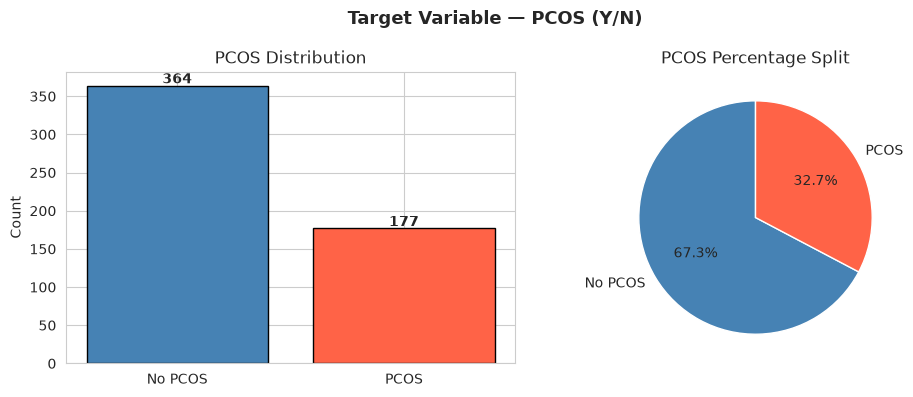

No PCOS: 364 (67.3%)
PCOS:    177 (32.7%)

Implication: the dataset is moderately imbalanced (~2:1).
A model that always predicts 'No PCOS' would get 67.3% accuracy without learning anything.
This is why accuracy alone cannot be used to evaluate models — recall, F1, and ROC-AUC
must be used instead, since they account for both classes separately.


In [2]:
target_col = 'PCOS (Y/N)'
counts = df_clean[target_col].value_counts()
pct = df_clean[target_col].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No PCOS', 'PCOS'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('PCOS Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No PCOS', 'PCOS'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('PCOS Percentage Split')

plt.suptitle('Target Variable — PCOS (Y/N)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"No PCOS: {counts[0]} ({pct[0]:.1f}%)")
print(f"PCOS:    {counts[1]} ({pct[1]:.1f}%)")
print()
print("Implication: the dataset is moderately imbalanced (~2:1).")
print("A model that always predicts 'No PCOS' would get 67.3% accuracy without learning anything.")
print("This is why accuracy alone cannot be used to evaluate models — recall, F1, and ROC-AUC")
print("must be used instead, since they account for both classes separately.")


### 6.2 — Demographic features

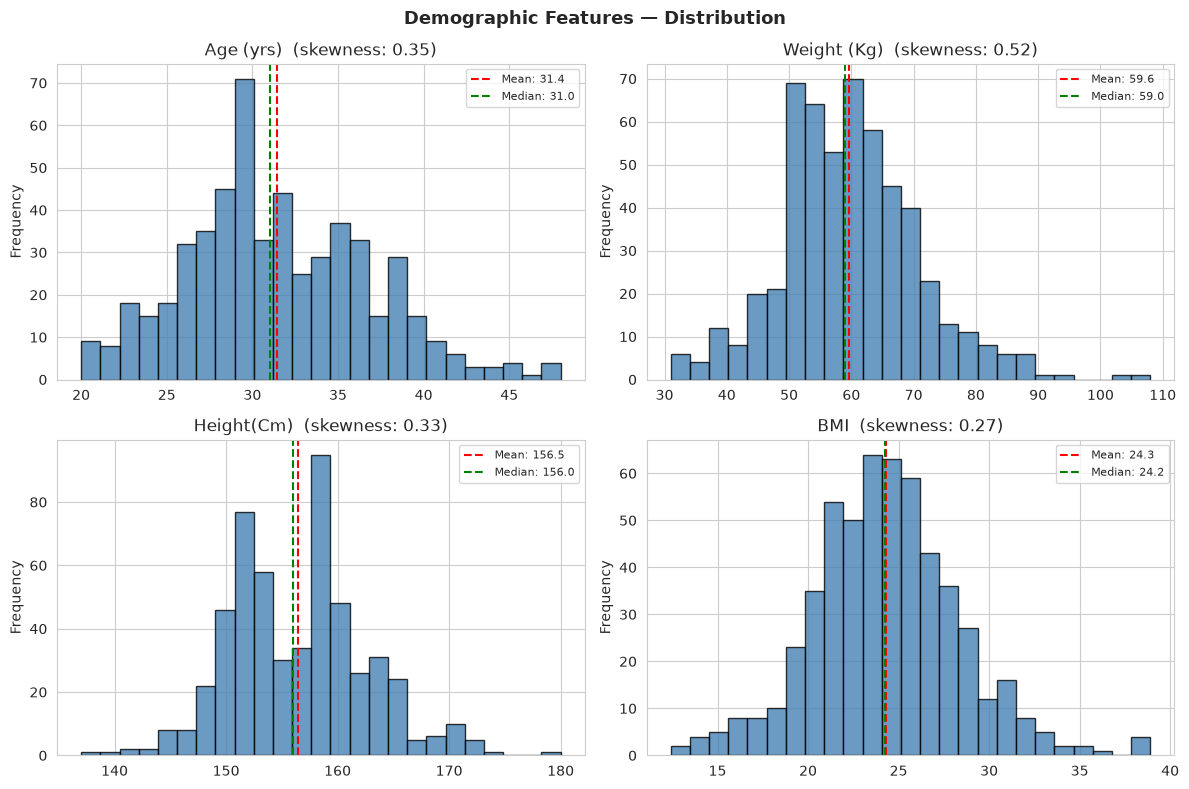

In [3]:
demo_cols = ['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    data = df_clean[col].dropna()
    skew_val = data.skew()
    axes[i].hist(data, bins=25, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(data.mean(),   color='red',   linestyle='--', label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'{col}  (skewness: {skew_val:.2f})')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Demographic Features — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Age, Weight, Height, and BMI are all roughly symmetric (skewness close to 0).  
Mean and median are very close for all four, which means there are no extreme outliers  
pulling the mean. These features are close to normally distributed.


### 6.3 — Hormonal features (with skewness check)

In [4]:
# First, compute skewness for all numeric features.
# Skewness > 1 or < -1 is generally considered significantly skewed.
# This is important because it determines which statistical tests are valid later.

numeric_cont = ['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
                'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
                'TSH (mIU/L)', 'PRL(ng/mL)', 'Hb(g/dl)', 'RBS(mg/dl)',
                'Follicle No. (L)', 'Follicle No. (R)', 'Waist:Hip Ratio',
                'Endometrium (mm)', 'Cycle length(days)']

skewness_df = df_clean[numeric_cont].skew().round(2).to_frame('Skewness')
skewness_df['Significantly Skewed (|skew|>1)'] = skewness_df['Skewness'].abs() > 1
print(skewness_df.sort_values('Skewness', ascending=False).to_string())


                    Skewness  Significantly Skewed (|skew|>1)
FSH(mIU/mL)            23.24                             True
LH(mIU/mL)             23.23                             True
FSH/LH                 21.46                             True
TSH (mIU/L)             9.79                             True
RBS(mg/dl)              5.49                             True
AMH(ng/mL)              3.29                             True
PRL(ng/mL)              2.44                             True
Follicle No. (L)        0.94                            False
Cycle length(days)      0.83                            False
Follicle No. (R)        0.79                            False
Hb(g/dl)                0.74                            False
Weight (Kg)             0.52                            False
Age (yrs)               0.35                            False
Height(Cm)              0.33                            False
BMI                     0.27                            False
Endometr

**Key finding:** FSH, LH, FSH/LH, and TSH have skewness values above 20.  
This is driven by a small number of extreme outliers (one patient has FSH > 5000 mIU/mL  
while the median is around 5). These extreme outliers heavily inflate the mean and standard  
deviation of these columns.

**Why this matters for Section 8:** Pearson correlation and Student's t-test both assume  
normality and are sensitive to outliers. For features this severely skewed, the non-parametric  
equivalents must be used:
- **Mann-Whitney U test** instead of t-test (compares rank-based distributions, not means)  
- **Spearman correlation** instead of Pearson (rank-based, not sensitive to outliers)


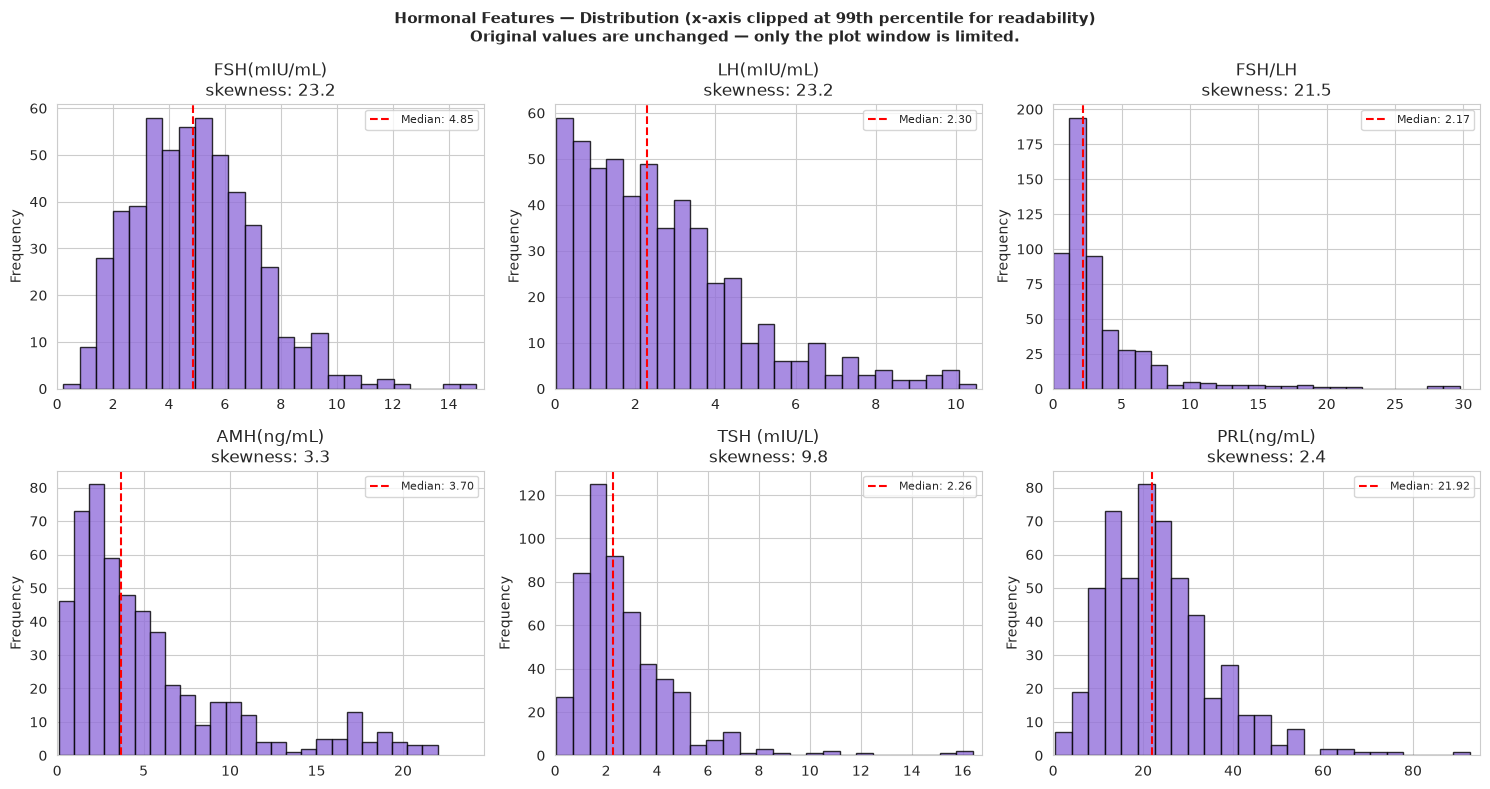

In [5]:
hormonal_cols = ['FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)', 'TSH (mIU/L)', 'PRL(ng/mL)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(hormonal_cols):
    data = df_clean[col].dropna()
    # Use 99th percentile as x-axis limit so extreme outliers don't squish the bulk of the data
    # Note: we are NOT removing these values — only limiting the visual x-axis range
    upper_limit = data.quantile(0.99)
    skew_val = data.skew()

    axes[i].hist(data[data <= upper_limit], bins=25, color='mediumpurple',
                 edgecolor='black', alpha=0.8)
    axes[i].axvline(data.median(), color='red', linestyle='--',
                    label=f'Median: {data.median():.2f}')
    axes[i].set_xlim(0, upper_limit)
    axes[i].set_title(f'{col}\nskewness: {skew_val:.1f}')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Hormonal Features — Distribution (x-axis clipped at 99th percentile for readability)\n'
             'Original values are unchanged — only the plot window is limited.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Why we use the median (red line) instead of mean here:** With skewness > 20 in FSH and LH,  
the mean is dramatically inflated by the top 1% of values. The median is a more  
representative measure of the "typical" value in skewed distributions.  

### 6.4 — Ultrasound features

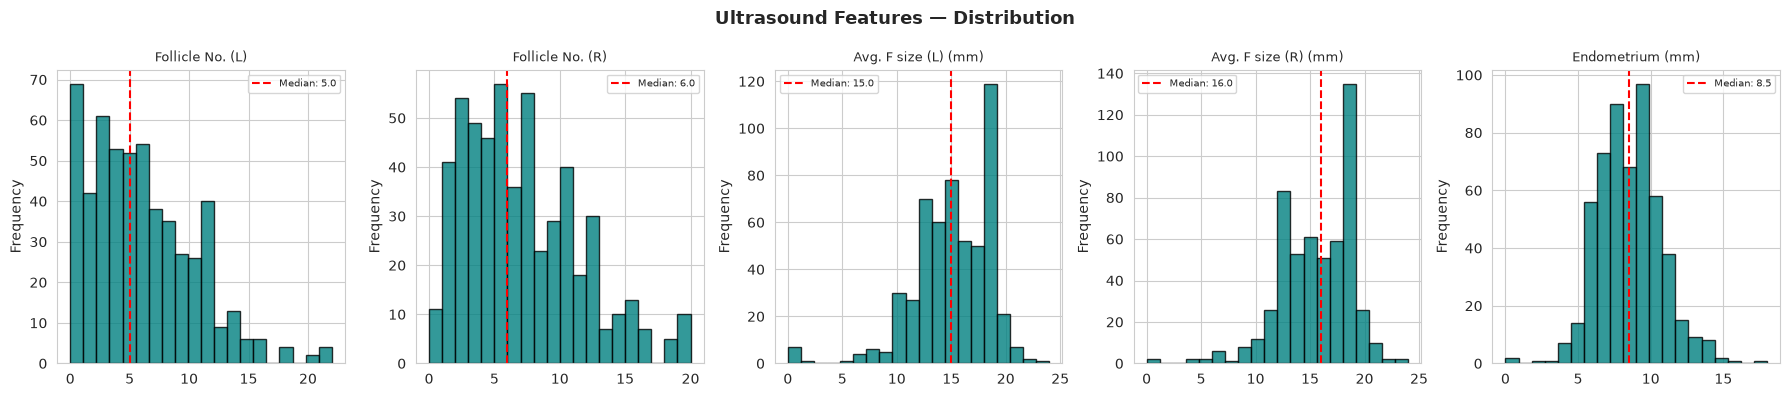

In [6]:
ultrasound_cols = ['Follicle No. (L)', 'Follicle No. (R)',
                   'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(ultrasound_cols):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=20, color='teal', edgecolor='black', alpha=0.8)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

plt.suptitle('Ultrasound Features — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.5 — Binary symptom and lifestyle features

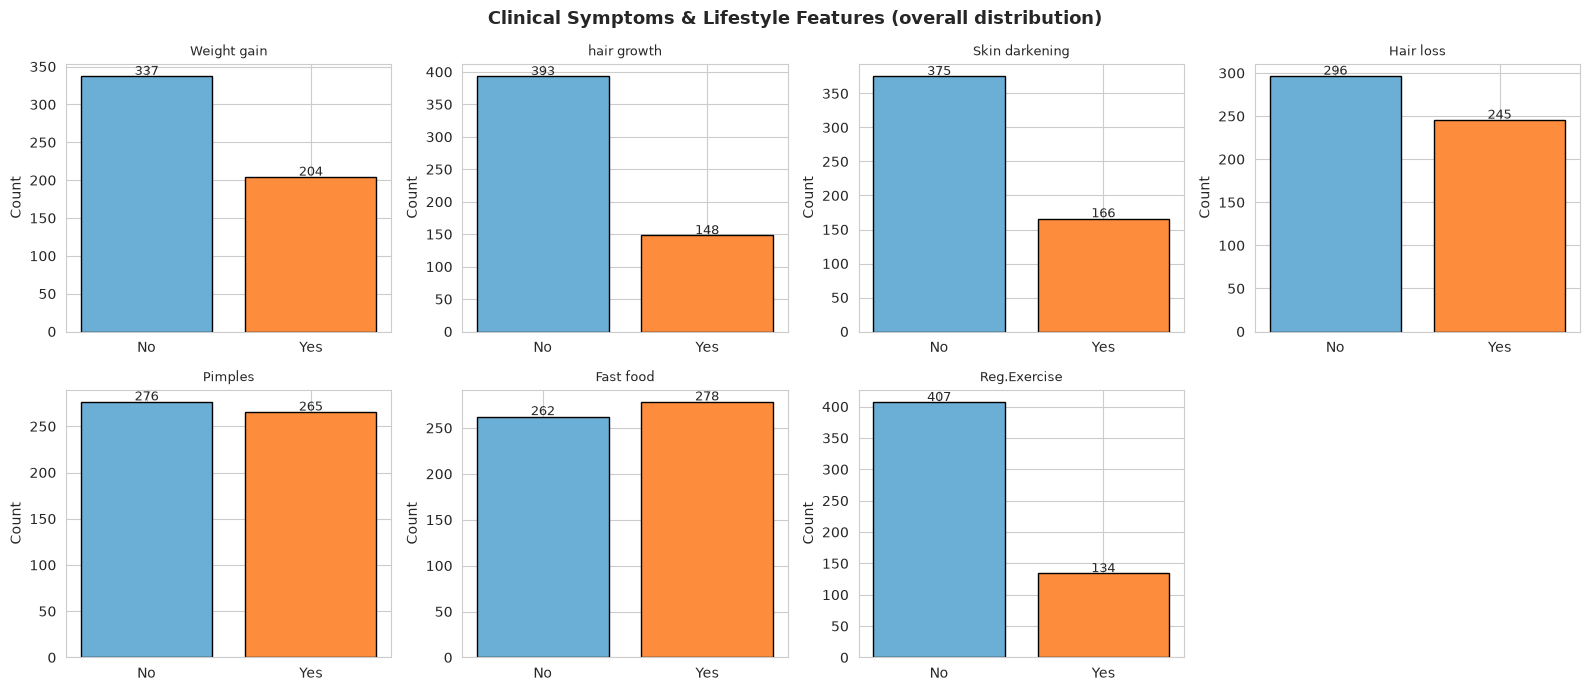

In [7]:
symptom_cols = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(symptom_cols):
    counts = df_clean[col].value_counts().reindex([0, 1], fill_value=0)
    axes[i].bar(['No', 'Yes'], counts.values, color=['#6baed6', '#fd8d3c'], edgecolor='black')
    axes[i].set_title(col.replace('(Y/N)', '').strip(), fontsize=9)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Clinical Symptoms & Lifestyle Features (overall distribution)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 7 — EDA: Bivariate Analysis
Now we split each feature by PCOS status to see which features show a visible difference  
between the two groups. These plots motivate the statistical tests in Section 8.


### 7.1 — Numeric features vs PCOS

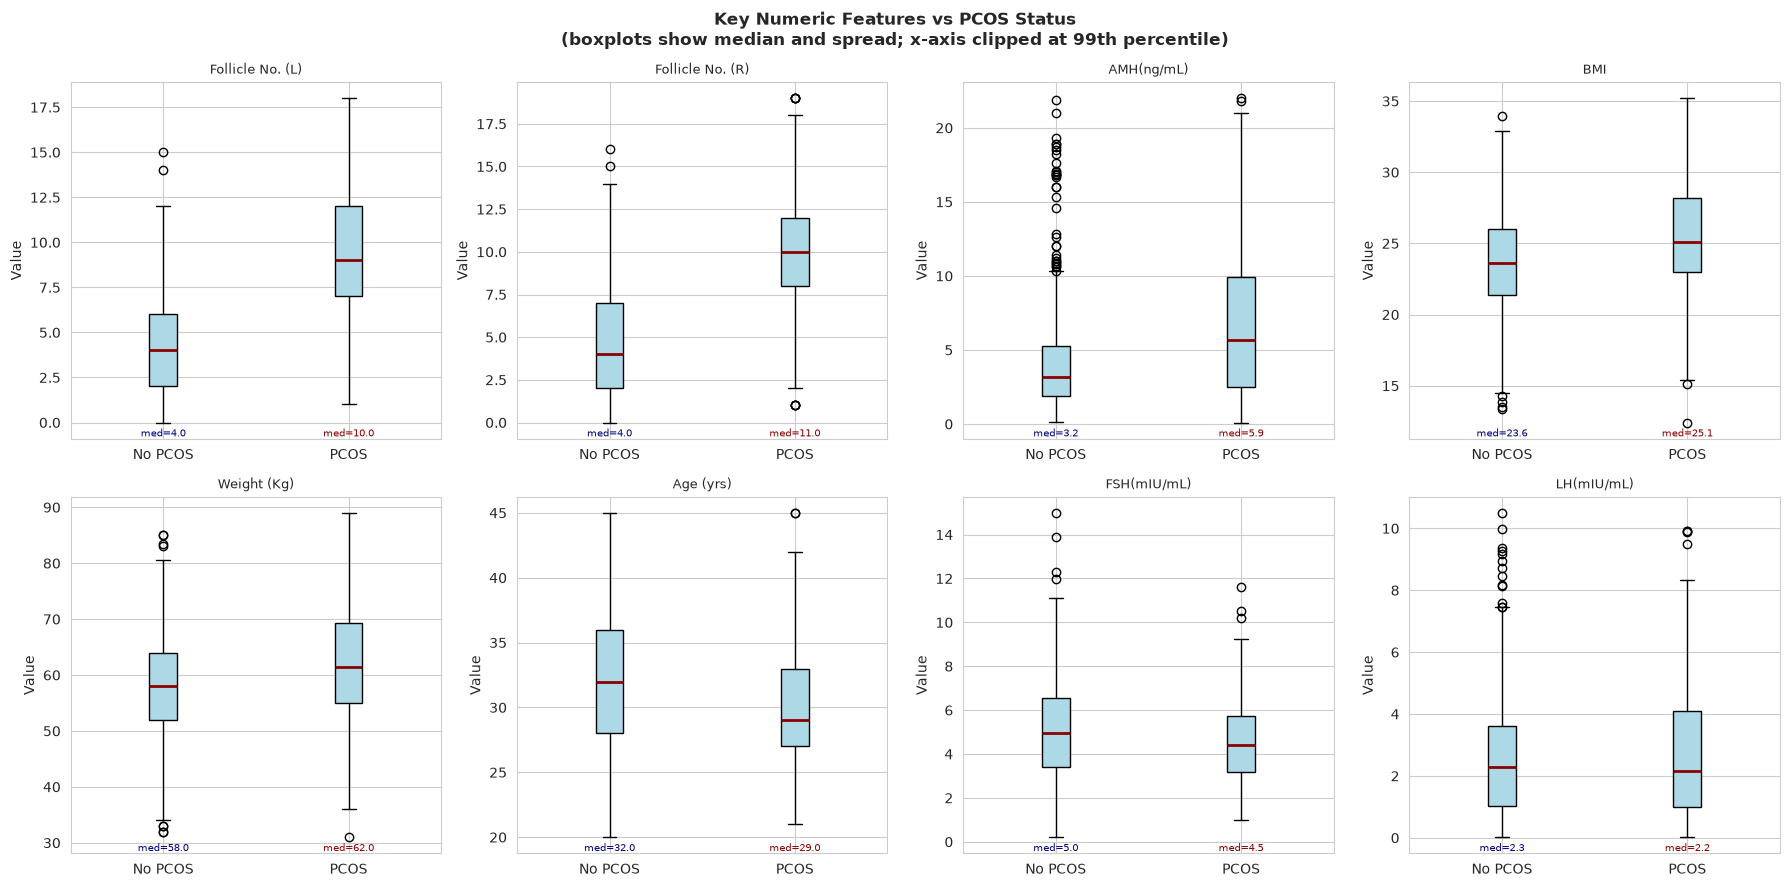

In [8]:
key_numeric = [
    'Follicle No. (L)', 'Follicle No. (R)', 'AMH(ng/mL)', 'BMI',
    'Weight (Kg)', 'Age (yrs)', 'FSH(mIU/mL)', 'LH(mIU/mL)'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_numeric):

    pcos_no = df_clean.loc[df_clean[target_col] == 0, col].dropna()
    pcos_yes = df_clean.loc[df_clean[target_col] == 1, col].dropna()

    # Clip at 99th percentile for visual clarity
    upper = df_clean[col].quantile(0.99)

    bp = axes[i].boxplot(
        [
            pcos_no[pcos_no <= upper],
            pcos_yes[pcos_yes <= upper]
        ],
        tick_labels=['No PCOS', 'PCOS'],   # <-- changed from labels=
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='darkred', linewidth=2)
    )

    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Value")

    ymin, ymax = axes[i].get_ylim()

    axes[i].text(
        1, ymin,
        f"med={pcos_no.median():.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="navy"
    )

    axes[i].text(
        2, ymin,
        f"med={pcos_yes.median():.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="darkred"
    )

plt.suptitle(
    "Key Numeric Features vs PCOS Status\n"
    "(boxplots show median and spread; x-axis clipped at 99th percentile)",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Observations:**
- **Follicle counts (L & R):** The clearest visual separation. PCOS median ~10-11 vs no-PCOS median ~4. This aligns with the clinical diagnostic criterion of "polycystic ovarian morphology" — ≥12 follicles per ovary.
- **AMH:** Higher in PCOS (median ~5.9 vs ~3.2). AMH is a direct marker of ovarian follicle count.
- **BMI and Weight:** Slightly higher in PCOS, with overlapping distributions.
- **Age:** PCOS patients are slightly *younger* on average (median 29 vs 32). Not counterintuitive — PCOS is most commonly diagnosed in younger reproductive years.
- **FSH and LH:** Almost no visual separation despite the extreme outliers. We will test this formally in Section 8.


### 7.2 — Symptom prevalence by PCOS status

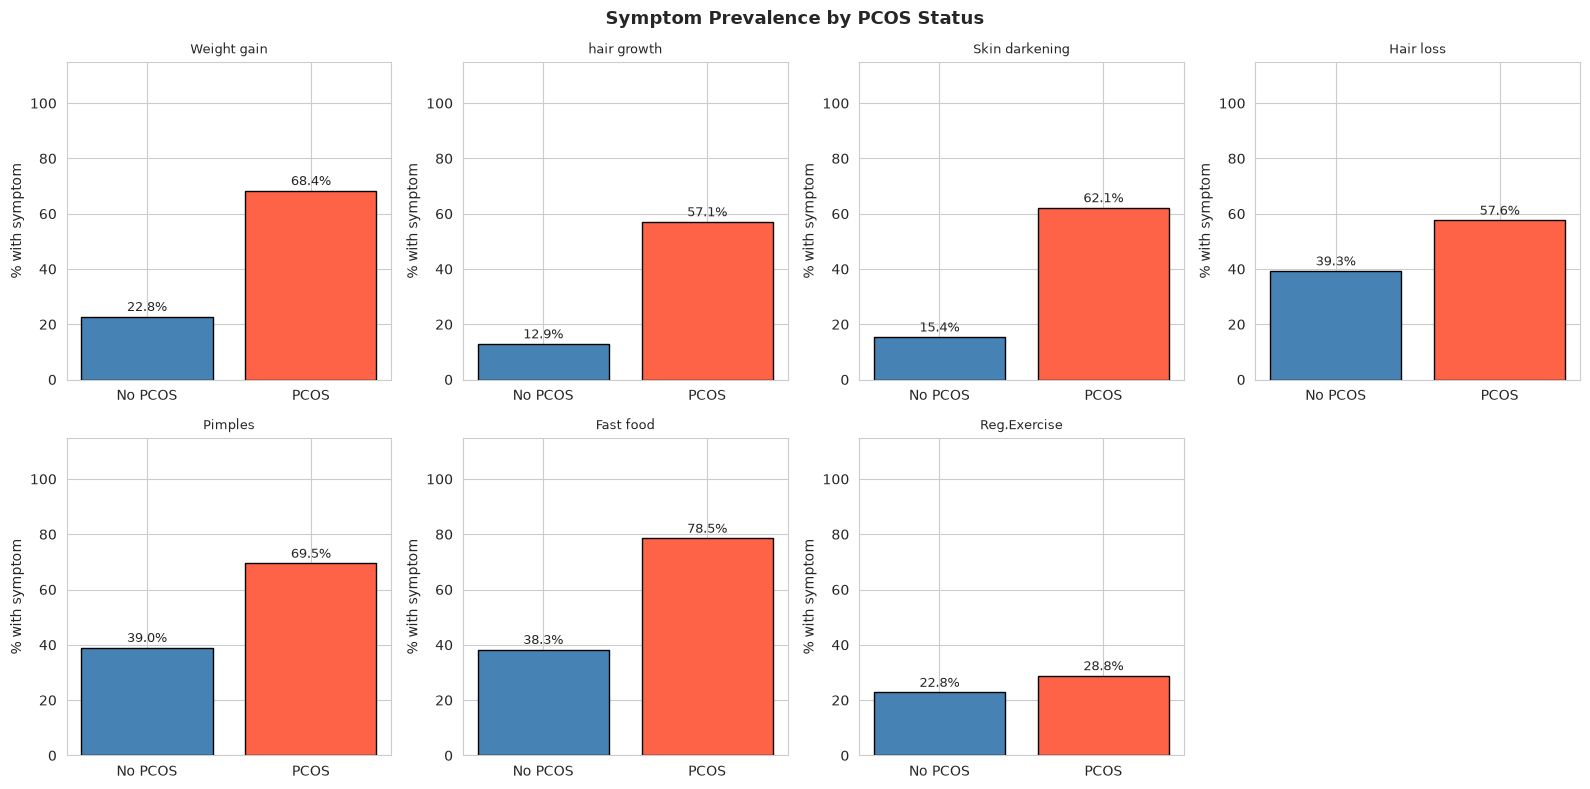

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(symptom_cols):
    pcos_rates = df_clean.groupby(target_col)[col].mean() * 100
    bars = axes[i].bar(['No PCOS', 'PCOS'], pcos_rates.values,
                       color=['steelblue', 'tomato'], edgecolor='black')
    axes[i].set_title(col.replace('(Y/N)', '').strip(), fontsize=9)
    axes[i].set_ylabel('% with symptom')
    axes[i].set_ylim(0, 115)
    for j, v in enumerate(pcos_rates.values):
        axes[i].text(j, v + 2, f'{v:.1f}%', ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Symptom Prevalence by PCOS Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations:**
- **Skin darkening, hair growth, weight gain, pimples:** All substantially more common in PCOS (~57-68%) vs no-PCOS (~13-35%).
- **Fast food:** 78% of PCOS patients vs 39% non-PCOS.
- **Regular exercise:** Similar in both groups (~22-27%) — not a strong differentiator.
These visible differences need formal statistical confirmation in Section 8.


### 8.1 — Normality check (justifying non-parametric tests)

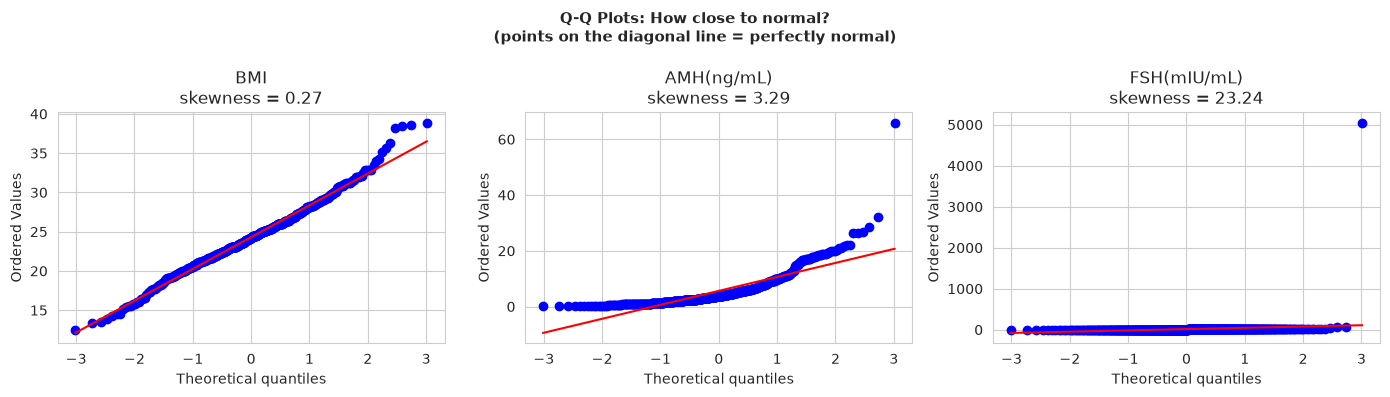

In [10]:
# We already computed skewness in Section 6.3.
# Here we also check visually using Q-Q plots for 3 representative features:
# one near-normal (BMI), one moderately skewed (AMH), one extremely skewed (FSH).

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['BMI', 'AMH(ng/mL)', 'FSH(mIU/mL)']):
    data = df_clean[col].dropna()
    stats.probplot(data, dist='norm', plot=ax)
    skew_v = data.skew()
    ax.set_title(f'{col}\nskewness = {skew_v:.2f}')
plt.suptitle('Q-Q Plots: How close to normal?\n'
             '(points on the diagonal line = perfectly normal)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


- **BMI** (skewness 0.27): points closely follow the diagonal — approximately normal.  
- **AMH** (skewness 3.29): clear deviation in the upper tail — moderately right-skewed.  
- **FSH** (skewness 23): extreme deviation — the distribution is not remotely normal.  

**Conclusion:** Parametric tests (t-test, Pearson) are appropriate only for features close  
to normal (e.g. BMI, Age, Height). For the majority of features — especially hormonal ones —  
we must use non-parametric alternatives.


### 8.2 — Mann-Whitney U test (numeric features vs PCOS target)

Because many numeric features are skewed and/or contain outliers, we use the non-parametric Mann-Whitney U test to compare PCOS vs non-PCOS groups.

In [11]:
# Mann-Whitney U tests whether the rank distribution of a numeric feature
# differs between PCOS and non-PCOS groups. It makes NO normality assumption
# and is not affected by extreme outliers.
#
# H0: The two groups have the same distribution (no difference).
# H1: The distributions are different.
# We reject H0 if p < 0.05.

numeric_features = [
    'Follicle No. (L)', 'Follicle No. (R)', 'AMH(ng/mL)', 'BMI',
    'Weight (Kg)', 'Age (yrs)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
    'Hb(g/dl)', 'RBS(mg/dl)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
    'PRL(ng/mL)', 'Height(Cm)', 'Endometrium (mm)', 'Cycle length(days)'
]

g0 = df_clean[df_clean[target_col] == 0]
g1 = df_clean[df_clean[target_col] == 1]

mw_results = []
for col in numeric_features:
    a = g0[col].dropna()
    b = g1[col].dropna()
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    mw_results.append({
        'Feature': col,
        'Median (No PCOS)': round(a.median(), 3),
        'Median (PCOS)':    round(b.median(), 3),
        'p-value':          p,
        'Significant (p<0.05)': p < 0.05
    })

mw_df = pd.DataFrame(mw_results).sort_values('p-value')
mw_df['p-value'] = mw_df['p-value'].apply(lambda x: f'{x:.2e}')
print(mw_df.to_string(index=False))


           Feature  Median (No PCOS)  Median (PCOS)  p-value  Significant (p<0.05)
  Follicle No. (R)             4.000         11.000 3.12e-48                  True
  Follicle No. (L)             4.000         10.000 1.69e-41                  True
Cycle length(days)             5.000          5.000 6.17e-09                  True
        AMH(ng/mL)             3.200          5.900 3.89e-08                  True
               BMI            23.600         25.100 5.16e-06                  True
       Weight (Kg)            58.000         62.000 5.84e-06                  True
         Age (yrs)            32.000         29.000 1.66e-05                  True
  Endometrium (mm)             8.300          8.900 4.51e-03                  True
            FSH/LH             2.364          2.036 6.01e-03                  True
       FSH(mIU/mL)             5.010          4.480 7.43e-03                  True
          Hb(g/dl)            11.000         11.000 2.47e-02                  True
    

**Notable result:** FSH and FSH/LH are statistically significant by Mann-Whitney U.

The extreme FSH outliers make the distribution highly skewed, which is exactly why the rank-based Mann-Whitney test is more reliable here than a t-test.

Features not significant in this first group include Height, LH, PRL, Waist:Hip Ratio, and TSH.

### 8.3 — Chi-square test (categorical features vs PCOS target)

In [12]:
# Chi-square test of independence: tests whether the distribution of a categorical
# variable is independent of PCOS status.
# H0: The categorical feature and PCOS status are independent (no association).
# H1: There is an association.

categorical_features = {
    'Symptom/Lifestyle (binary)': ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                                    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
                                    'Reg.Exercise(Y/N)', 'Pregnant(Y/N)'],
    'Clinical (categorical)':     ['Cycle(R/I)', 'Blood Group']
}

chi_results = []
for group, cols in categorical_features.items():
    for col in cols:
        mask = df_clean[col].notna()
        ct = pd.crosstab(df_clean.loc[mask, col], df_clean.loc[mask, target_col])
        chi2, p, dof, _ = chi2_contingency(ct)
        cv = cramers_v(df_clean[col], df_clean[target_col])
        chi_results.append({
            'Group': group, 'Feature': col,
            'Chi2': round(chi2, 2), 'p-value': p,
            'Cramér\'s V': round(cv, 3),
            'Significant (p<0.05)': p < 0.05
        })

chi_df = pd.DataFrame(chi_results).sort_values('p-value')
chi_df['p-value'] = chi_df['p-value'].apply(lambda x: f'{x:.2e}')
print(chi_df.to_string(index=False))


                     Group              Feature   Chi2  p-value  Cramér's V  Significant (p<0.05)
Symptom/Lifestyle (binary) Skin darkening (Y/N) 120.25 5.57e-28       0.476                  True
Symptom/Lifestyle (binary)     hair growth(Y/N) 114.60 9.63e-27       0.465                  True
Symptom/Lifestyle (binary)     Weight gain(Y/N) 103.31 2.87e-24       0.441                  True
    Clinical (categorical)           Cycle(R/I)  83.62 6.00e-20       0.398                  True
Symptom/Lifestyle (binary)      Fast food (Y/N)  75.53 3.60e-18       0.378                  True
Symptom/Lifestyle (binary)         Pimples(Y/N)  43.06 5.30e-11       0.286                  True
Symptom/Lifestyle (binary)       Hair loss(Y/N)  15.44 8.53e-05       0.173                  True
Symptom/Lifestyle (binary)    Reg.Exercise(Y/N)   2.00 1.57e-01       0.065                 False
Symptom/Lifestyle (binary)        Pregnant(Y/N)   0.30 5.85e-01       0.028                 False
    Clinical (catego

**Key results:**
- All clinical symptom features (skin darkening, hair growth, weight gain, irregular cycles, fast food, pimples, hair loss) are **highly significant** (p < 0.0001). Their Cramér's V values (0.3–0.5) indicate moderate-to-strong association.
- **Regular exercise** (p = 0.16) and **Pregnant** (p = 0.58) are not significantly associated with PCOS.
- **Blood Group** (p = 0.96): absolutely no association with PCOS. This confirms that including Blood Group in the Pearson correlation matrix — which produced a small correlation coefficient — was giving a meaningless number, not evidence of an association.


### 8.4 — Ranked feature associations with PCOS target

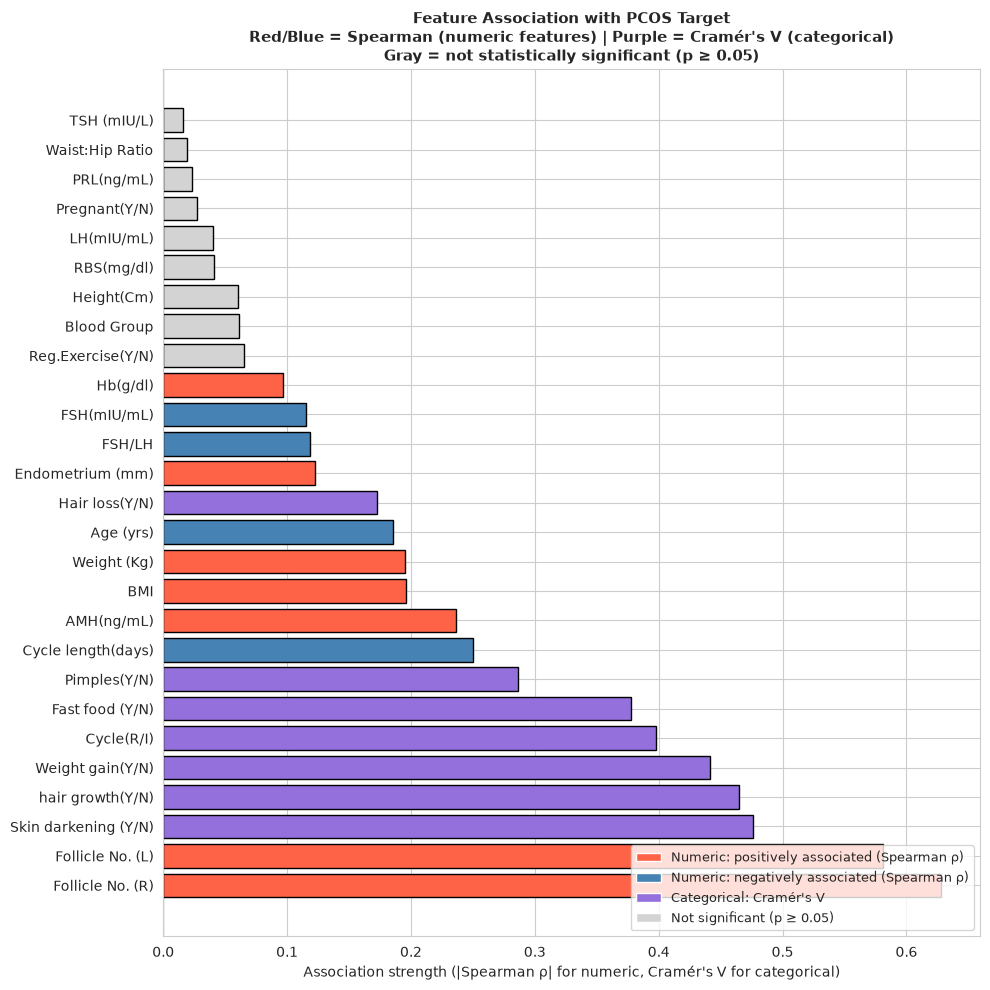


Top 10 features by association strength:
             Feature  Association      Measure  Significant
    Follicle No. (R)     0.627988 Spearman |ρ|         True
    Follicle No. (L)     0.580721 Spearman |ρ|         True
Skin darkening (Y/N)     0.475733   Cramér's V         True
    hair growth(Y/N)     0.464667   Cramér's V         True
    Weight gain(Y/N)     0.441047   Cramér's V         True
          Cycle(R/I)     0.397917   Cramér's V         True
     Fast food (Y/N)     0.377933   Cramér's V         True
        Pimples(Y/N)     0.286077   Cramér's V         True
  Cycle length(days)     0.250131 Spearman |ρ|         True
          AMH(ng/mL)     0.236723 Spearman |ρ|         True


In [13]:
# Combine association measures into one ranked chart.
# For numeric features: Spearman correlation coefficient (rank-based, appropriate for skewed data).
# For binary/categorical features: Cramér's V.
# This replaces the Pearson correlation bar chart from the previous version.

assoc_records = []

# Numeric: Spearman with binary target (valid because Spearman is rank-based and
# works for any monotonic relationship, even with a binary variable)
for col in numeric_features:
    mask = df_clean[col].notna()
    rho, p = stats.spearmanr(df_clean.loc[mask, col], df_clean.loc[mask, target_col])
    assoc_records.append({
        'Feature': col, 'Association': abs(rho),
        'Direction': '+' if rho > 0 else '-',
        'Measure': 'Spearman |ρ|', 'Significant': p < 0.05
    })

# Categorical: Cramér's V
for group, cols in categorical_features.items():
    for col in cols:
        cv = cramers_v(df_clean[col], df_clean[target_col])
        mask = df_clean[col].notna()
        ct = pd.crosstab(df_clean.loc[mask, col], df_clean.loc[mask, target_col])
        _, p, _, _ = chi2_contingency(ct)
        assoc_records.append({
            'Feature': col, 'Association': cv,
            'Direction': '+',  # Cramér's V is always non-negative
            'Measure': 'Cramér\'s V', 'Significant': p < 0.05
        })

assoc_df = pd.DataFrame(assoc_records).sort_values('Association', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
colors = []
for _, row in assoc_df.iterrows():
    if not row['Significant']:
        colors.append('lightgray')
    elif row['Measure'] == 'Spearman |ρ|':
        colors.append('tomato' if row['Direction'] == '+' else 'steelblue')
    else:
        colors.append('mediumpurple')

bars = ax.barh(assoc_df['Feature'], assoc_df['Association'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Association strength (|Spearman ρ| for numeric, Cramér\'s V for categorical)')
ax.set_title('Feature Association with PCOS Target\n'
             'Red/Blue = Spearman (numeric features) | Purple = Cramér\'s V (categorical)\n'
             'Gray = not statistically significant (p ≥ 0.05)',
             fontsize=11, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',     label='Numeric: positively associated (Spearman ρ)'),
    Patch(facecolor='steelblue',  label='Numeric: negatively associated (Spearman ρ)'),
    Patch(facecolor='mediumpurple', label='Categorical: Cramér\'s V'),
    Patch(facecolor='lightgray',  label='Not significant (p ≥ 0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features by association strength:")
print(assoc_df[['Feature', 'Association', 'Measure', 'Significant']].head(10).to_string(index=False))


# Section 9 — Feature–Feature Spearman Correlation

This section examines how **continuous numerical features relate to each other** (not to the PCOS target).

Understanding these relationships helps identify:

1. **Redundant features** that carry similar information.
2. **Potential multicollinearity**, which may affect certain machine learning models and statistical analyses.
3. **Clinically meaningful associations** between physiological and hormonal measurements.

## Why Spearman Correlation Instead of Pearson?

Earlier exploratory analysis (Section 6.3) showed that many variables—particularly hormonal measurements—are **highly right-skewed** and contain **extreme outliers**. Since Pearson correlation is sensitive to outliers and assumes approximately normal data for reliable inference, **Spearman's rank correlation** is a more appropriate choice.

Spearman correlation:

- Uses the **ranks** of observations instead of their raw values.
- Measures the strength and direction of a **monotonic relationship**.
- Does **not require normally distributed data**.
- Is **less sensitive to extreme outliers** than Pearson correlation.
- Can detect both **linear and non-linear monotonic relationships**.

## Statistical Logic

For two variables **X** and **Y**:

1. Replace each observation with its rank.
2. Compute the correlation between the ranked observations.
3. The resulting Spearman correlation coefficient (**ρ**) ranges from **−1 to +1**.

Interpretation:

- **ρ = +1** → Perfect positive monotonic relationship.
- **ρ = 0** → No monotonic association.
- **ρ = −1** → Perfect negative monotonic relationship.

Unlike Pearson correlation, Spearman measures **monotonic association**, not necessarily a linear relationship.

## Assumptions

Spearman correlation requires:

- Independent observations.
- Variables measured on at least an **ordinal scale** (continuous variables satisfy this requirement).
- An approximately **monotonic relationship** for meaningful interpretation.

Unlike Pearson correlation, **normality, homoscedasticity, and linearity are not required**.

## Variables Included

Only **genuinely continuous numerical variables** are included in this analysis.

Categorical variables such as **Blood Group**, **Cycle (R/I)**, and binary **Yes/No** variables are excluded because their numerical encoding is arbitrary, making correlation coefficients statistically uninterpretable.

## Interpreting the Correlation Matrix

| Absolute Spearman Correlation (\|ρ\|) | Interpretation |
|:--------------------------------------|:---------------|
| < 0.30                                | Weak association |
| 0.30–0.69                             | Moderate association |
| ≥ 0.70                                | Strong association |

Feature pairs with **high absolute correlations** may indicate redundant information and should be considered during feature selection or when assessing multicollinearity before model development.

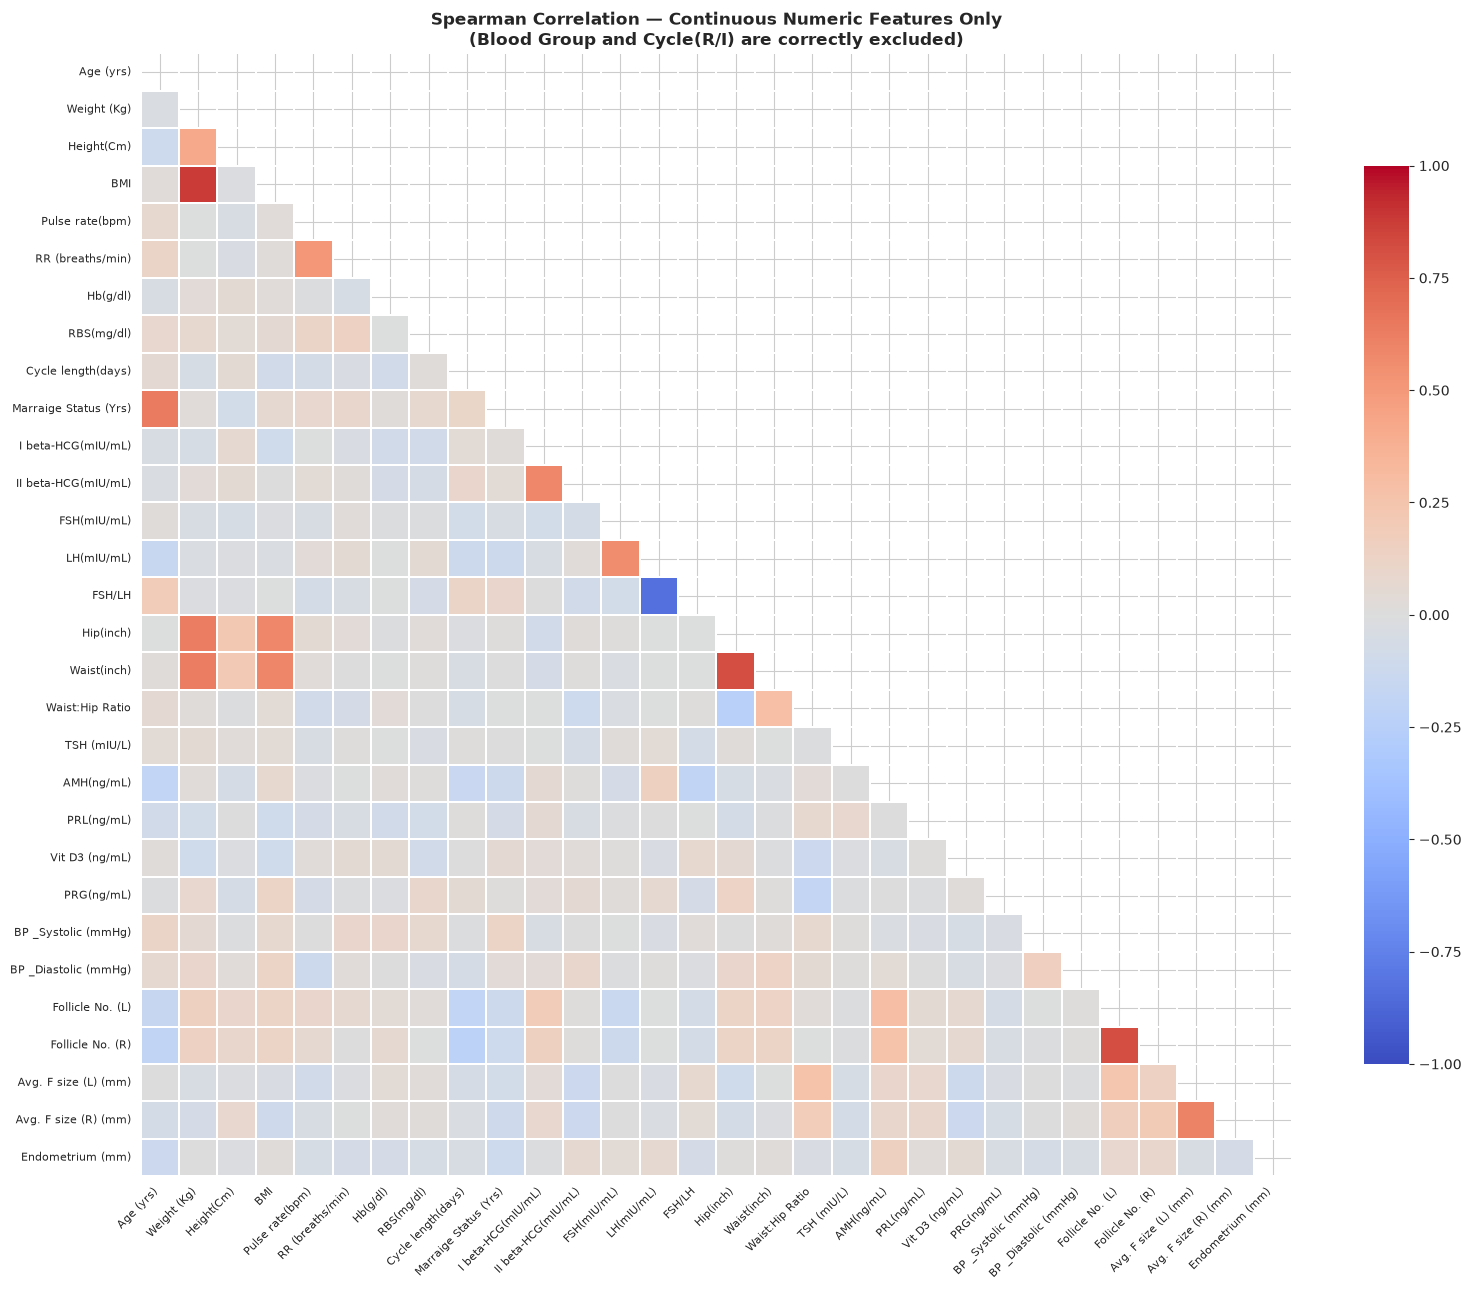

In [14]:
# Continuous numeric features only (no Blood Group, no Cycle R/I, no binary Y/N columns)
continuous_only = [
    'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
    'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'RBS(mg/dl)',
    'Cycle length(days)', 'Marraige Status (Yrs)',
    'I beta-HCG(mIU/mL)', 'II beta-HCG(mIU/mL)',
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
    'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
    'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
    'PRG(ng/mL)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'
]

# Compute Spearman correlation matrix
spearman_corr = df_clean[continuous_only].corr(method='spearman')

# Plot (lower triangle only — upper triangle is redundant)
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(spearman_corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Spearman Correlation — Continuous Numeric Features Only\n'
             '(Blood Group and Cycle(R/I) are correctly excluded)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# Identify the strongest feature-feature correlations
# ============================================================

# Remove duplicate pairs and self-correlations
corr_pairs = (
    spearman_corr.where(np.tril(np.ones(spearman_corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Spearman rho"]

# Sort by absolute correlation
corr_pairs["Absolute rho"] = corr_pairs["Spearman rho"].abs()

strong_corr = (
    corr_pairs
    .sort_values("Absolute rho", ascending=False)
    .drop(columns="Absolute rho")
)

print("All pairwise Spearman correlations (sorted by absolute value):\n")
print(strong_corr.to_string(index=False))

All pairwise Spearman correlations (sorted by absolute value):

            Feature 1             Feature 2  Spearman rho
                  BMI           Weight (Kg)      0.877728
               FSH/LH            LH(mIU/mL)     -0.829746
     Follicle No. (R)      Follicle No. (L)      0.819964
          Waist(inch)             Hip(inch)      0.817510
Marraige Status (Yrs)             Age (yrs)      0.634908
          Waist(inch)           Weight (Kg)      0.631157
            Hip(inch)           Weight (Kg)      0.630741
 Avg. F size (R) (mm)  Avg. F size (L) (mm)      0.604612
          Waist(inch)                   BMI      0.591271
  II beta-HCG(mIU/mL)    I beta-HCG(mIU/mL)      0.582840
            Hip(inch)                   BMI      0.579514
           LH(mIU/mL)           FSH(mIU/mL)      0.555739
     RR (breaths/min)       Pulse rate(bpm)      0.508095
           Height(Cm)           Weight (Kg)      0.420201
     Follicle No. (L)            AMH(ng/mL)      0.294996
      Wa

In [16]:
print("Known multicollinearity examples\n")

# FSH, LH, FSH/LH
triad = ['FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH']

print("FSH, LH and FSH/LH:")
print(df_clean[triad].corr(method='spearman').round(3))

print("\nInterpretation:")
print("- FSH/LH is mathematically derived from FSH and LH.")
print("- These variables contain overlapping information.")
print("- During model development, only one representative variable should be retained if multicollinearity becomes problematic.")

print("\n")

# Waist group
waist_group = ['Waist(inch)', 'Hip(inch)', 'Waist:Hip Ratio']

print("Waist-related variables:")
print(df_clean[waist_group].corr(method='spearman').round(3))

print("\nInterpretation:")
print("- Waist and Hip circumference are strongly positively correlated.")
print("- Waist:Hip Ratio is derived from Waist and Hip measurements.")
print("- These variables should also be checked during feature selection.")

Known multicollinearity examples

FSH, LH and FSH/LH:
             FSH(mIU/mL)  LH(mIU/mL)  FSH/LH
FSH(mIU/mL)        1.000       0.556  -0.079
LH(mIU/mL)         0.556       1.000  -0.830
FSH/LH            -0.079      -0.830   1.000

Interpretation:
- FSH/LH is mathematically derived from FSH and LH.
- These variables contain overlapping information.
- During model development, only one representative variable should be retained if multicollinearity becomes problematic.


Waist-related variables:
                 Waist(inch)  Hip(inch)  Waist:Hip Ratio
Waist(inch)            1.000      0.818            0.289
Hip(inch)              0.818      1.000           -0.247
Waist:Hip Ratio        0.289     -0.247            1.000

Interpretation:
- Waist and Hip circumference are strongly positively correlated.
- Waist:Hip Ratio is derived from Waist and Hip measurements.
- These variables should also be checked during feature selection.


## Section 10 — EDA Summary & Key Findings

### Data quality issues found and fixed

| Issue | Column | Fix applied |
|---|---|---|
| Whitespace in column headers | Multiple | Stripped and compressed |
| Non-numeric value `'a'` | AMH(ng/mL), row 306 | Set to NaN |
| Double decimal typo `'1.99.'` | II beta-HCG(mIU/mL), row 124 | Stripped dot → numeric |
| Invalid category code (5) | Cycle(R/I), row 513 | Set to NaN |
| Impossible BP: systolic = 12 mmHg | BP Systolic, 1 row | Corrected to 120 |
| Impossible BP: diastolic = 8 mmHg | BP Diastolic, 1 row | Corrected to 80 |
| Identifier/empty columns | Sl. No, Patient File No., Unnamed: 44 | Dropped |

---

### What we found in EDA

**Strongest signals (well-separated PCOS vs no-PCOS, statistically significant):**
- **Follicle counts** (L & R): median 10-11 in PCOS vs 4 in no-PCOS. Most powerful signal. Directly corresponds to the "polycystic ovarian morphology" criterion in clinical PCOS diagnosis.
- **AMH**: median 5.9 vs 3.2 ng/mL. AMH is a direct proxy for follicle count and is the strongest hormonal signal.
- **BMI and Weight**: PCOS patients are on average heavier, consistent with PCOS being a metabolic syndrome.
- **Age**: PCOS patients are slightly younger (median 29 vs 32). This is expected — PCOS is typically diagnosed in early reproductive years.
- **Symptom features** (skin darkening, hair growth, weight gain, pimples, hair loss, fast food, irregular cycle): all strongly associated by chi-square, Cramér's V 0.3–0.5.

**Features that look relevant but require the right test:**
- **FSH and FSH/LH**: NOT significant by Welch's t-test (as used in the previous version), but **significant by Mann-Whitney U** (p ≈ 0.006–0.007). The t-test failed because extreme FSH outliers inflated variance beyond what the test could handle. This illustrates why test choice matters.

**Features with no significant association with PCOS:**
- **LH, TSH, PRL, Waist:Hip Ratio, Height**: not statistically significant by Mann-Whitney U.
- **Blood Group**: p = 0.96 (chi-square) — essentially random with respect to PCOS. This also confirms that the correlation coefficient shown in the previous notebook for Blood Group was meaningless.
- **Reg.Exercise** and **Pregnant**: not significant by chi-square.

**Multicollinearity to handle before modeling:**
- FSH, LH, FSH/LH: FSH/LH is algebraically derived — keep only one of the three.
- Waist, Hip, Waist:Hip Ratio: the ratio is derived — keep the ratio OR the raw measurements, not both.
- Follicle No. (L) and Follicle No. (R) are very highly correlated (Spearman ≈ 0.83) — consider averaging them or using one.

---
